In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  df = pd.read_csv(filename)
  print(f"Successfully loaded '{filename}' into a DataFrame.")
  break

print(df.head())

Saving Customer_Segmentation_py.csv to Customer_Segmentation_py (3).csv
Successfully loaded 'Customer_Segmentation_py (3).csv' into a DataFrame.
         Date  Day     Month  Year  Customer_Age       Age_Group  \
0  26/11/2013   26  November  2013            19     Youth (<25)   
1  26/11/2015   26  November  2015            19     Youth (<25)   
2  23/03/2014   23     March  2014            49  Adults (35-64)   
3  23/03/2016   23     March  2016            49  Adults (35-64)   
4  15/05/2014   15       May  2014            47  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales

In [ ]:
print(df.columns)


Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')


In [ ]:
print(df.columns.tolist())
df['Customer_ID'] = (
    df['Customer_Age'].astype(str) + "_" +
    df['Customer_Gender'].astype(str) + "_" +
    df['Country'].astype(str) + "_" +
    df['State'].astype(str)
)
customer_summary = df.groupby('Customer_ID').agg({
    'Revenue':'sum',
    'Profit':'sum',
    'Order_Quantity':'sum'
}).reset_index()

print(customer_summary.head())

['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue', 'Customer_ID', 'Order_Value']
                      Customer_ID  Revenue  Profit  Order_Quantity
0  17_F_Australia_New South Wales    19446    6124             442
1       17_F_Australia_Queensland    25066    6961             319
2  17_F_Australia_South Australia     1329     444               3
3         17_F_Australia_Tasmania    10540    2400              10
4         17_F_Australia_Victoria    30628    9615             584


In [ ]:
frequency = df.groupby('Customer_ID')['Order_Quantity'].count().reset_index()
frequency.rename(columns={'Order_Quantity':'Frequency'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
last_purchase = df.groupby('Customer_ID')['Date'].max().reset_index()
last_purchase['Recency'] = (df['Date'].max() - last_purchase['Date']).dt.days
df['Order_Value'] = df['Revenue']
aov = df.groupby('Customer_ID')['Order_Value'].mean().reset_index()
aov.rename(columns={'Order_Value':'AOV'}, inplace=True)


In [ ]:
customer_features = frequency.merge(
    last_purchase[['Customer_ID','Recency']], on='Customer_ID'
)
customer_features = customer_features.merge(aov, on='Customer_ID')
print(customer_features.head())


                      Customer_ID  Frequency  Recency          AOV
0  17_F_Australia_New South Wales         40       41   486.150000
1       17_F_Australia_Queensland         28       45   895.214286
2  17_F_Australia_South Australia          2     1467   664.500000
3         17_F_Australia_Tasmania          4      242  2635.000000
4         17_F_Australia_Victoria         46      122   665.826087


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [ ]:
!pip install --upgrade scikit-learn


In [ ]:

%pip install --upgrade scikit-learn


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Random Forest R2:", r2_score(y_test, rf_preds))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))

print("XGBoost R2:", r2_score(y_test, xgb_preds))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))

Random Forest R2: 0.9943292384656802
Random Forest RMSE: 4479.604838780006
XGBoost R2: 0.9925917983055115
XGBoost RMSE: 5120.061913688154


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest R2:", rf_r2)
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost R2:", xgb_r2)
print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)


Random Forest R2: 0.9943292384656802
Random Forest MAE: 1326.0537182448031
Random Forest RMSE: 4479.604838780006
XGBoost R2: 0.9925917983055115
XGBoost MAE: 2010.7421875
XGBoost RMSE: 5120.061913688154


In [ ]:
results = X_test.copy()
results['Actual_Revenue'] = y_test.values
results['Predicted_LTV_RF'] = rf_preds
results['Predicted_LTV_XGB'] = xgb_preds

print(results.head())


      Frequency  Recency      AOV  Actual_Revenue  Predicted_LTV_RF  \
1134          2      314    35.00              70             77.77   
670           4       46  1604.50            6418           6189.27   
965          10      185    63.40             634            673.90   
1754          8      117   402.25            3218           3213.35   
2058         12      129   324.25            3891           3888.55   

      Predicted_LTV_XGB  
1134          80.583885  
670         6466.365234  
965          867.466309  
1754        3380.765869  
2058        3516.225342  


In [ ]:
import pandas as pd
results['Segment'] = pd.qcut(results['Predicted_LTV_RF'],
                             q=3,
                             labels=['Low LTV','Medium LTV','High LTV'])

print(results[['Customer_ID','Predicted_LTV_RF','Segment']].head(10))


                           Customer_ID  Predicted_LTV_RF     Segment
1134        39_F_France_Seine et Marne             77.77     Low LTV
670           30_F_Germany_Brandenburg           6189.27     Low LTV
965               35_M_Germany_Hamburg            673.90     Low LTV
1754               53_M_France_Moselle           3213.35     Low LTV
2058              64_F_Germany_Hamburg           3888.55     Low LTV
1783  54_F_Germany_Nordrhein-Westfalen          20168.26  Medium LTV
1701              52_F_Germany_Hamburg           5383.95     Low LTV
1084                 38_F_France_Somme          15933.03  Medium LTV
1263         42_F_Australia_Queensland          52561.25    High LTV
915              34_M_Germany_Saarland          28369.45  Medium LTV


In [ ]:

results = X_test.copy()
results['Customer_ID'] = customer_features.loc[X_test.index, 'Customer_ID'].values
results['Actual_Revenue'] = y_test.values
results['Predicted_LTV_RF'] = rf_preds
results['Predicted_LTV_XGB'] = xgb_preds

print(results.head())


      Frequency  Recency      AOV                 Customer_ID  Actual_Revenue  \
1134          2      314    35.00  39_F_France_Seine et Marne              70   
670           4       46  1604.50    30_F_Germany_Brandenburg            6418   
965          10      185    63.40        35_M_Germany_Hamburg             634   
1754          8      117   402.25         53_M_France_Moselle            3218   
2058         12      129   324.25        64_F_Germany_Hamburg            3891   

      Predicted_LTV_RF  Predicted_LTV_XGB  
1134             77.77          80.583885  
670            6189.27        6466.365234  
965             673.90         867.466309  
1754           3213.35        3380.765869  
2058           3888.55        3516.225342  


In [ ]:
segment_summary = results.groupby('Segment').agg({
    'Predicted_LTV_RF':'mean',
    'Actual_Revenue':'mean',
    'Customer_ID':'count'
}).rename(columns={'Customer_ID':'Customer_Count'})

print(segment_summary)

            Predicted_LTV_RF  Actual_Revenue  Customer_Count
Segment                                                     
Low LTV          2370.061597     2344.215278             144
Medium LTV      17702.508958    17627.194444             144
High LTV        94902.494897    96095.800000             145


/tmp/ipython-input-12378/1450354803.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = results.groupby('Segment').agg({


/tmp/ipython-input-12378/1277513663.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby('Segment')['Predicted_LTV_RF'].mean().plot(kind='bar')


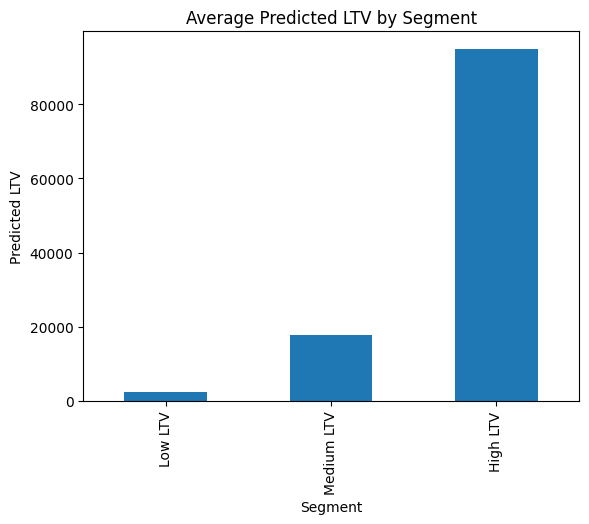

In [ ]:
import matplotlib.pyplot as plt

results.groupby('Segment')['Predicted_LTV_RF'].mean().plot(kind='bar')
plt.title("Average Predicted LTV by Segment")
plt.ylabel("Predicted LTV")
plt.show()

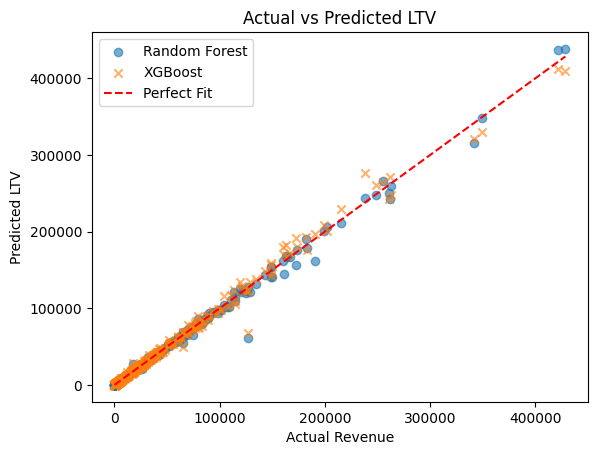

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(results['Actual_Revenue'], results['Predicted_LTV_RF'], alpha=0.6, label="Random Forest")
plt.scatter(results['Actual_Revenue'], results['Predicted_LTV_XGB'], alpha=0.6, label="XGBoost", marker='x')
plt.plot([results['Actual_Revenue'].min(), results['Actual_Revenue'].max()],
         [results['Actual_Revenue'].min(), results['Actual_Revenue'].max()],
         'r--', label="Perfect Fit")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV")
plt.legend()
plt.show()


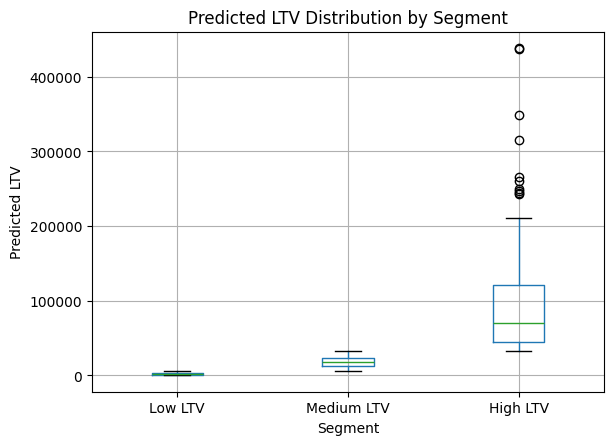

In [ ]:
results.boxplot(column='Predicted_LTV_RF', by='Segment')
plt.title("Predicted LTV Distribution by Segment")
plt.suptitle("")
plt.ylabel("Predicted LTV")
plt.show()

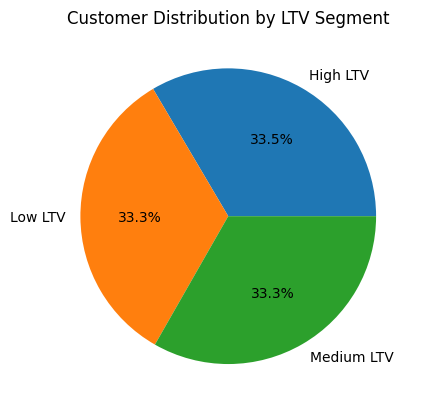

In [ ]:
results['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Distribution by LTV Segment")
plt.ylabel("")
plt.show()